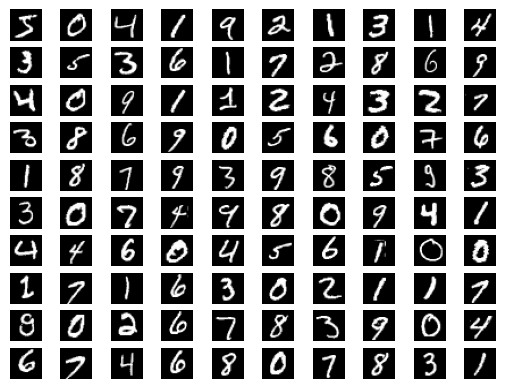

In [1]:
import numpy as np
from mnist import MNIST
import matplotlib.pyplot as plt

# load MNIST data
mndata = MNIST(
    '/Users/boo/Desktop/coding/Deep_Learning/MNIST')
mndata.gz = True
# loading training data and testing data
x_train, _ = mndata.load_training()
x_test, _ = mndata.load_testing()
# visualize the data
x_train = np.array(x_train) / 255.0
x_test = np.array(x_test) / 255.0
fig, axs = plt.subplots(10, 10)
for i, ax in enumerate(axs.flat):
    ax.imshow(x_train[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

In [2]:
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

In [3]:
W1 = np.random.randn(x_train.shape[1], 64) * 0.01
b1 = np.zeros((1, 64))
W2 = np.random.randn(64,x_train.shape[1])*0.01
b2 = np.zeros((1, x_train.shape[1]))


In [4]:
def relu(x):
    return np.maximum(0, x)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [8]:
def encoder(x):
    z1 = np.dot(x, W1) + b1
    a1 = relu(z1)
    return a1,z1

def decoder(x):
    z2 = np.dot(x, W2) + b2
    a2 = sigmoid(z2)
    return a2

num_epochs = 51 # setting number of epochs
batch_size = 256 # setting batch size
num_batches = x_train.shape[0] // batch_size # setting number of batches
learning_rate = 0.0001 # setting learning rate

for epoch in range(num_epochs):
    total_loss = 0.0
    for batch in range(num_batches):
        batch_indices = np.random.choice(x_train.shape[0], batch_size)
        x_batch = x_train[batch_indices]
        a1,z1 = encoder(x_batch)
        x_hat = decoder(a1)
        loss = np.mean((x_hat - x_batch)**2)
        total_loss += loss
        # backpropagation
        dL_dx_hat = x_hat - x_batch
        dL_dz2 = dL_dx_hat * x_hat * (1 - x_hat)
        dL_dW2 = np.dot(a1.T, dL_dz2)
        dL_db2 = np.sum(dL_dz2, axis=0)

        dL_da1 = np.dot(dL_dz2, W2.T)
        dL_dz1 = dL_da1 * (z1 > 0)
        dL_dW1 = np.dot(x_batch.T, dL_dz1)
        dL_db1 = np.sum(dL_dz1, axis=0)

        W2 -= learning_rate * dL_dW2
        b2 -= learning_rate * dL_db2
        W1 -= learning_rate * dL_dW1
        b1 -= learning_rate * dL_db1
    if epoch % 10 == 0:
        print("Epoch %d, loss = %.4f" % (epoch, total_loss ))




Epoch 0, loss = 1.1088
Epoch 10, loss = 1.0478
Epoch 20, loss = 1.0116
Epoch 30, loss = 0.9862
Epoch 40, loss = 0.9660
Epoch 50, loss = 0.9488


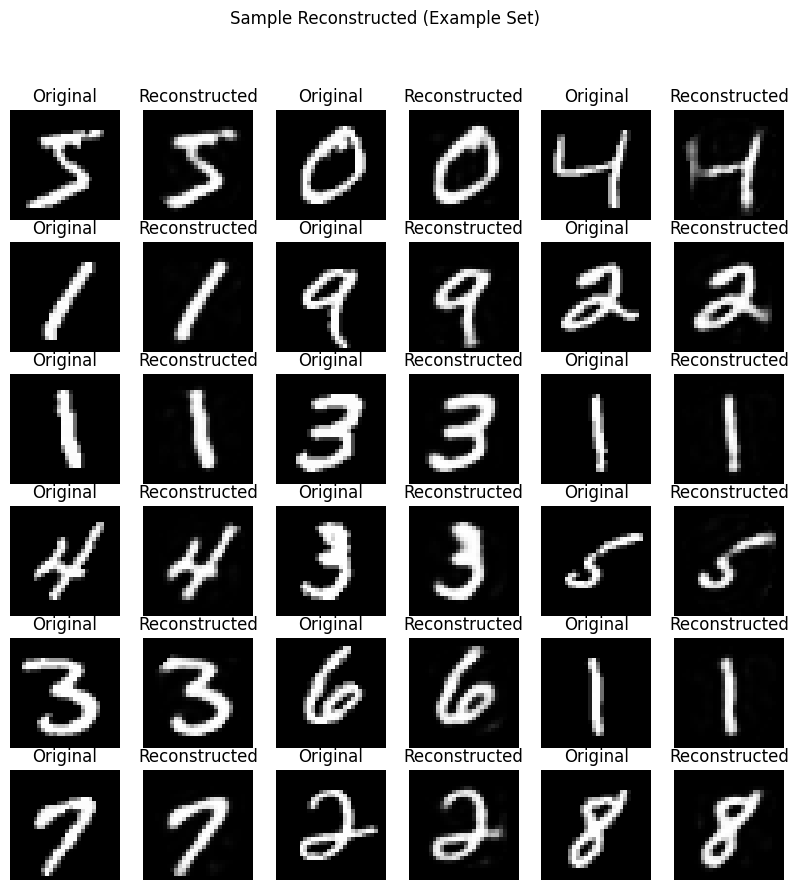

In [9]:
fig, axs = plt.subplots(6, 6, figsize=(10, 10))
x_hat = decoder(encoder(x_train)[0])
for i in range(6):
    for j in range(3):
        # Plot the original image
        ax = axs[i, j*2]
        ax.imshow(x_train[i*3+j].reshape(28, 28), cmap='gray')
        ax.set_title('Original')
        ax.axis('off')

        # Plot the reconstructed image
        ax = axs[i, j*2+1]
        ax.imshow(x_hat[i*3+j].reshape(28, 28), cmap='gray')
        ax.set_title('Reconstructed')
        ax.axis('off')
        
fig.suptitle('Sample Reconstructed (Example Set)')

plt.show()



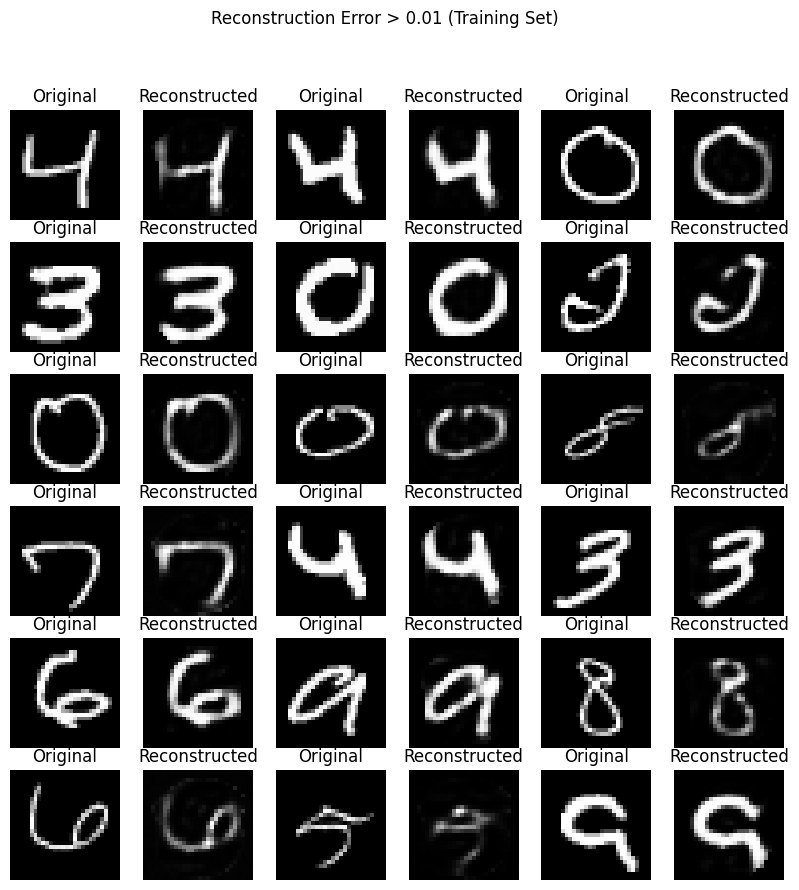

In [10]:
threshold = 0.01
fig, axs = plt.subplots(6, 6, figsize=(10, 10))
x_hat = decoder(encoder(x_train)[0])
count = 0
for i in range(len(x_train)):
    # Compute the reconstructed image
    x_hat_i = x_hat[i]

    # Compute the difference between the input and reconstructed images
    diff = np.mean((x_train[i] - x_hat_i)**2)

    # Plot the input and reconstructed images if the difference is above the threshold
    if diff > threshold:
        # Plot the original image
        ax = axs[count // 3, (count % 3) * 2]
        ax.imshow(x_train[i].reshape(28, 28), cmap='gray')
        ax.set_title('Original')
        ax.axis('off')

        # Plot the reconstructed image
        ax = axs[count // 3, (count % 3) * 2 + 1]
        ax.imshow(x_hat_i.reshape(28, 28), cmap='gray')
        ax.set_title('Reconstructed')
        ax.axis('off')

        count += 1

        # Break out of the loop if we have plotted 18 error cases
        if count == 18:
            break
fig.suptitle('Reconstruction Error > 0.01 (Training Set)')
plt.show()

In [12]:
encoded_imgs,_ = encoder(x_test)
decoded_imgs = decoder(encoded_imgs)
print("Loss = %f" % np.mean((x_test - decoded_imgs)**2))

Loss = 0.003959


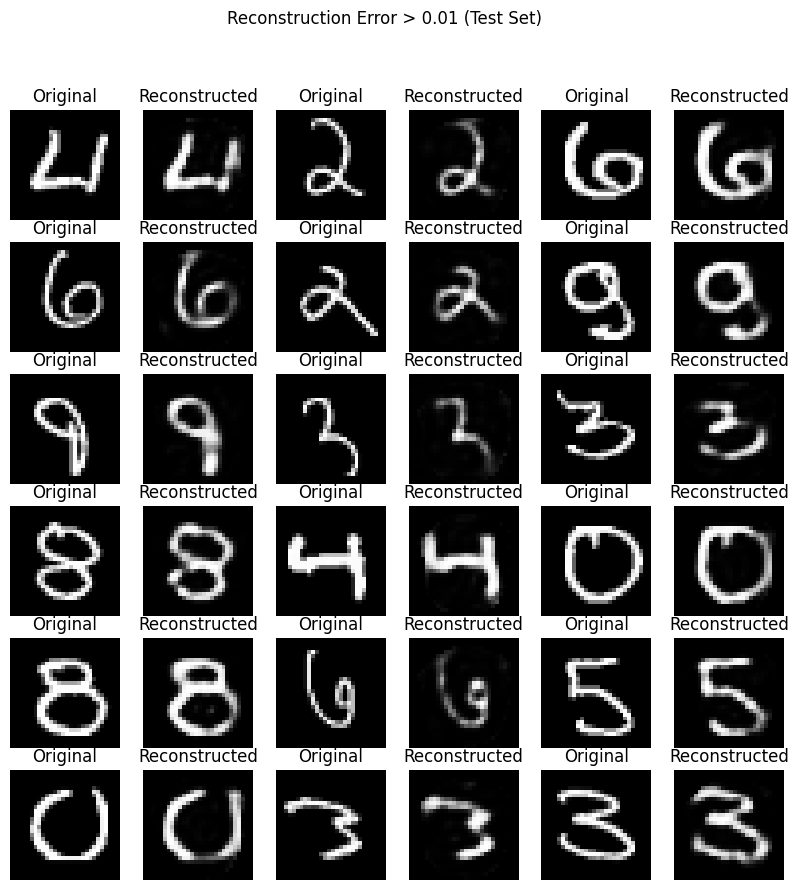

In [13]:
threshold = 0.01
fig, axs = plt.subplots(6, 6, figsize=(10, 10))
x_hat = decoded_imgs
count = 0
for i in range(len(x_test)):
    # Compute the reconstructed image
    x_hat_i = x_hat[i]

    # Compute the difference between the input and reconstructed images
    diff = np.mean((x_test[i] - x_hat_i)**2)

    # Plot the input and reconstructed images if the difference is above the threshold
    if diff > threshold:
        # Plot the original image
        ax = axs[count // 3, (count % 3) * 2]
        ax.imshow(x_test[i].reshape(28, 28), cmap='gray')
        ax.set_title('Original')
        ax.axis('off')

        # Plot the reconstructed image
        ax = axs[count // 3, (count % 3) * 2 + 1]
        ax.imshow(x_hat_i.reshape(28, 28), cmap='gray')
        ax.set_title('Reconstructed')
        ax.axis('off')

        count += 1

        # Break out of the loop if we have plotted 18 error cases
        if count == 18:
            break
fig.suptitle('Reconstruction Error > 0.01 (Test Set)')
plt.show()